<a href="https://colab.research.google.com/github/jawa1273io/Java001/blob/main/Copy_of_01ML_data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing tool

Importing the libraryy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Importing the dataset


In [ ]:
dataset = pd.read_csv('Data.csv')
x = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(x)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [ ]:
print(y)

['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


Taking care of mising data

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(x[:, 1:3])
x[:, 1:3] = imputer.transform(x[:, 1:3])

for 1D
a = np.array([10, 20, 30, 40, 50])

a[1:4]   # [20, 30, 40]  → index 1 to 3
a[:3]    # [10, 20, 30]  → from beginning
a[2:]    # [30, 40, 50]  → to end
a[:]     # everything
a[-1]    # 50            → last element

for 2D

X = np.array([[1,  2,  3],
              [4,  5,  6],
              [7,  8,  9]])

X[0, :]      # row 0        → [1, 2, 3]
X[:, 0]      # column 0     → [1, 4, 7]
X[:, 1:3]    # all rows, columns 1-2 → [[2, 3],
             #                          [5, 6],
             #                          [8, 9]]
X[0:2, 1:3]  # rows 0-1, columns 1-2 → [[2, 3],
             #                          [5, 6]]

In [ ]:
print(x)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


Encoding Categorical data

> Encoding the Independent Variable



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [ ]:
print(x)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 38.77777777777778 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


Encoding the dependent variable


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(y)

[0 1 0 0 1 1 0 1 0 1]


In [ ]:
print(y)

[0 1 0 0 1 1 0 1 0 1]


# splitting the dataset into training set and test set

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 1)







x — Your feature data (input variables)
y — Your target data (output/labels you're predicting)
test_size=0.2 — Uses 20% of data for testing, 80% for training
random_state=1 — Ensures reproducible splits (same split every time you run the code)
random_state=1 is a seed for the random number generator that controls how your data gets shuffled and split. It ensures reproducibility — the same split every time you run the code.

Why You Need It
Without random_state, each time you run train_test_split(), you get a different random split:




random state = 1, we are fixing the seeds only

In [ ]:
print(x_train)

[[0.0 0.0 1.0 38.77777777777778 52000.0]
 [0.0 1.0 0.0 40.0 63777.77777777778]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


In [ ]:
print(x_test)

[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [ ]:
print(y_train)

[0 1 0 0 1 1 0 1]


In [ ]:
print(y_test)

[0 1]


## Feature Scaling

Some features are dominated by other features,which all of our fetures in same scale

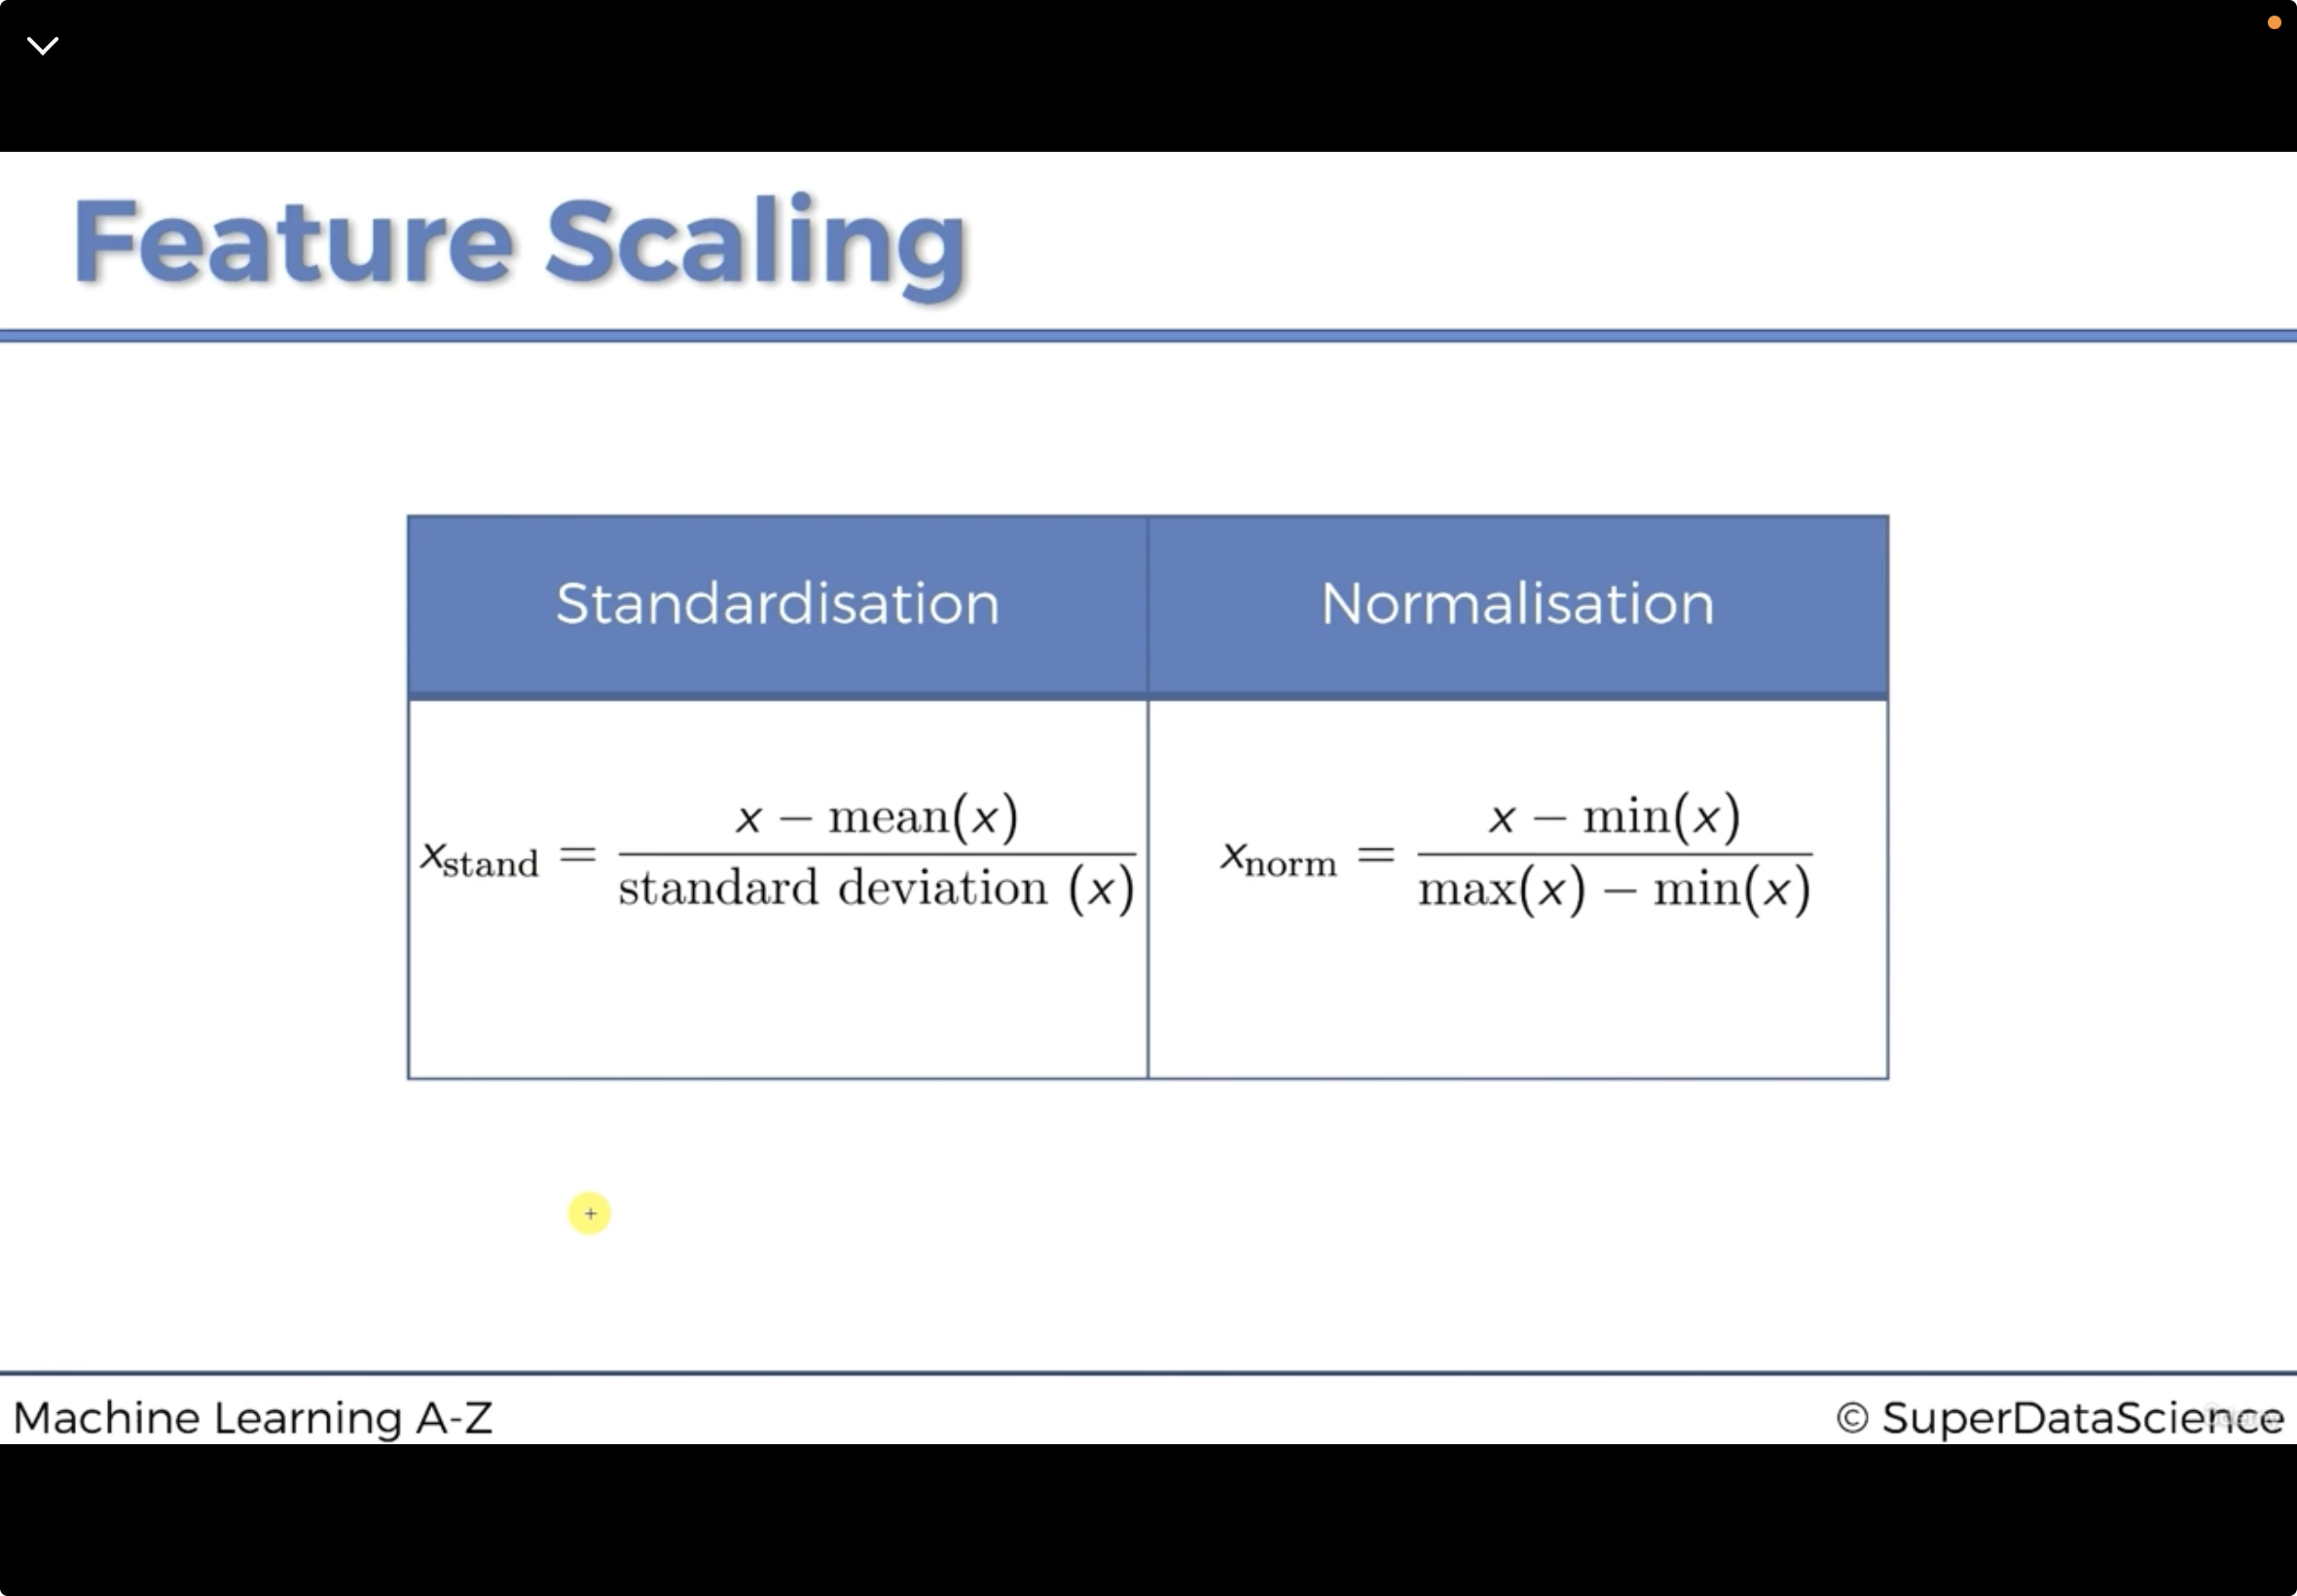

all the value -3 to +3 all # features after standardisation.
all the value between 0 and 1 # features after noramlisation

#Great question for Data Dcience Community.
should we go for standardisation or Normalisation
